# 04 — Canopy Height Model (CHM)

$$\text{CHM} = \text{DSM} - \text{DTM}$$

Computed per DTM variant so we can both **reproduce the poster** (VANT-CHM and
dGNSS-CHM vs the 11 field-measured tree heights) and **add the bias-corrected
CHM**. The DSM (~3.4 cm) is resampled onto the 0.5 m DTM grid via WarpedVRT
(streamed, never fully in memory). Negatives are clamped to 0; nodata preserved.

Tree height is read as the **maximum CHM within a crown radius** of each
dGNSS tree position (the GPS marks the trunk; the apex sits nearby).

**Inputs:** `data/talar_dsm.tif`, `data/pastizal_dsm.tif`, DTM variants
(`data/talar_dtm.tif` = Pix4D/VANT, `data/gnss_dtm.tif` = dGNSS,
`outputs/03_corrected/talar_dtm_corrected_0p5m.tif` = corrected canonical),
`data/Trees.shp` (11 trees, `RF height`, species).

**Outputs:** `outputs/04_chm/` — CHM rasters per variant + zone, a validation
table, and the scatter figures.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

from drone_reserve.chm import compute_chm, sample_chm_heights
from drone_reserve.dtm import residual_stats

for parent in [Path.cwd(), *Path.cwd().parents]:
    if (parent / "pyproject.toml").is_file():
        REPO = parent; break
else:
    raise RuntimeError("repo root not found")

DATA = REPO / "data"
CORR = REPO / "outputs" / "03_corrected"
OUT  = REPO / "outputs" / "04_chm"
FIGS = OUT / "figs"
OUT.mkdir(parents=True, exist_ok=True); FIGS.mkdir(parents=True, exist_ok=True)

# Talar DTM variants. Common output grid = the gap-free corrected DTM (0.5 m).
REF_GRID = CORR / "talar_dtm_corrected_0p5m.tif"
DTM_VARIANTS = {
    "VANT":      DATA / "talar_dtm.tif",                 # Pix4D DTM -> reproduces poster VANT-CHM
    "dGNSS":     DATA / "gnss_dtm.tif",                  # reproduces poster dGNSS-CHM (partial extent)
    "Corrected": CORR / "talar_dtm_corrected_0p5m.tif",  # SMRF + affine dGNSS correction + gap-fill (new)
}
DSM_TALAR = DATA / "talar_dsm.tif"

# Growth form for the poster's Arbol/Arbusto split. NOTE: best-guess mapping —
# Chilca (Baccharis) and Cola de Zorro are shrubs/grass; verify if needed.
SHRUBS = {"Chilca", "Cola de Zorro"}
print("OK")

OK


## Field trees (11) with rangefinder heights

In [2]:
# Prefer the manually QC'd positions if present (under-canopy dGNSS is off by metres;
# trees were repositioned onto their crowns in QGIS). Falls back to the raw file.
trees_qc = DATA / "Trees_qc.shp"
trees_path = trees_qc if trees_qc.exists() else DATA / "Trees.shp"
trees = gpd.read_file(trees_path, encoding="latin1")
assert trees.crs.to_epsg() == 32721 and len(trees) == 11
trees["growth_form"] = np.where(trees["Species"].isin(SHRUBS), "Arbusto", "Arbol")
print(f"Using tree positions from: {trees_path.name}"
      f"{'  (QC' + chr(39) + 'd)' if trees_path == trees_qc else '  (RAW — run QGIS QC for better tree validation)'}")
trees[["id", "GPS id", "Species", "RF height", "growth_form"]]

Using tree positions from: Trees.shp  (RAW — run QGIS QC for better tree validation)


,id,GPS id,Species,RF height,growth_form
0,2,7,Sauce Criollo,10.44,Arbol
1,1,10,Morus sp.,4.00,Arbol
2,3,11,Tala,6.63,Arbol
3,4,12,Tala,10.21,Arbol
4,5,15,Fumo Bravo,5.87,Arbol
5,6,16,Tala,7.16,Arbol
6,7,18,OmbÃº,5.72,Arbol
7,8,31,Cola de Zorro,2.44,Arbusto
8,9,35,Chilca,2.20,Arbusto
9,10,37,Chilca,3.10,Arbusto


## Compute CHM per variant and validate against the 11 trees

In [3]:
meas = trees["RF height"].to_numpy(float)
rows, heights = [], {}
for name, dtm in DTM_VARIANTS.items():
    out = OUT / f"talar_chm_{name.lower()}_0p5m.tif"
    res = compute_chm(DSM_TALAR, dtm, out, ref_grid_path=REF_GRID)
    h = sample_chm_heights(out, trees, radius_m=1.0, stat="max")  # crown-max; positions QC'd onto crowns
    heights[name] = h
    ok = np.isfinite(h) & np.isfinite(meas)
    s = residual_stats(h, meas)
    pr = pearsonr(meas[ok], h[ok])[0] if ok.sum() > 2 else np.nan
    rows.append({"variant": name, "n_trees": int(ok.sum()), "pearson_r": pr,
                 "rmse": s.rmse, "mae": s.mae, "bias": s.bias})
    print(f"{name:7s} CHM px={res.n_valid:,} range[{res.chm_min:.1f},{res.chm_max:.1f}] mean={res.chm_mean:.2f}")

validation = pd.DataFrame(rows).set_index("variant")
pd.set_option("display.float_format", lambda v: f"{v:.3f}")
validation

VANT    CHM px=474,183 range[0.0,14.1] mean=1.83


dGNSS   CHM px=139,990 range[0.0,11.1] mean=2.46


Corrected CHM px=474,780 range[0.0,17.4] mean=1.59


,n_trees,pearson_r,rmse,mae,bias
variant,,,,,
VANT,11,0.930,1.992,1.583,1.301
dGNSS,10,0.953,0.983,0.720,0.410
Corrected,11,0.974,0.875,0.665,0.188


## CHM vs field height — reproduce the poster (VANT, dGNSS) + add Corrected

Poster reported Pearson r = 0.95-0.98 for VANT-CHM and dGNSS-CHM. Colours follow
the poster's Arbol/Arbusto split.

C:\Users\paco_\AppData\Local\Temp\ipykernel_11176\3216924972.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.tight_layout(); fig.savefig(FIGS / "chm_vs_field_height.png", dpi=150); fig.show()


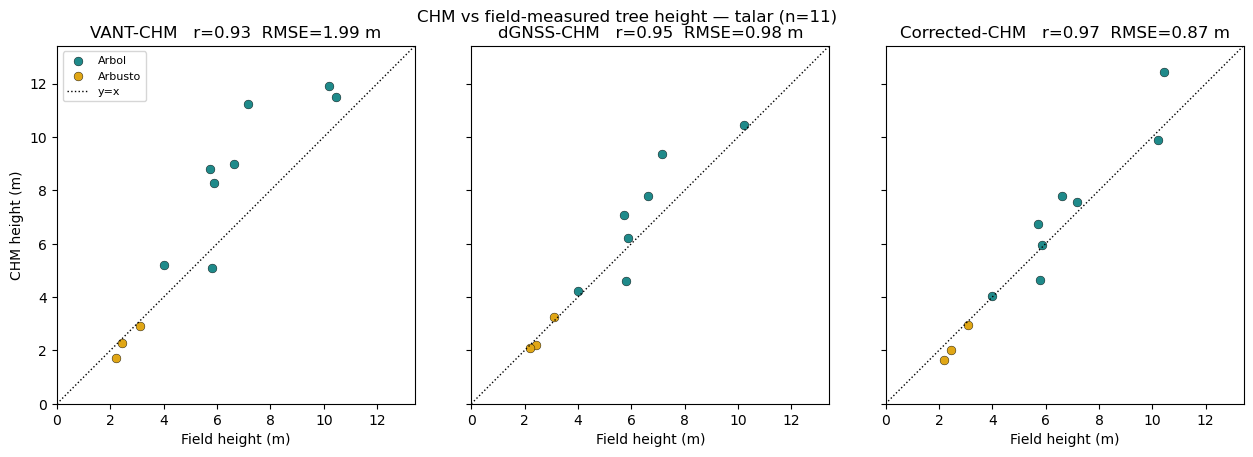

In [4]:
gf = trees["growth_form"].to_numpy()
order = ["VANT", "dGNSS", "Corrected"]
hi = max(np.nanmax(meas), *(np.nanmax(heights[k]) for k in order)) + 1
fig, axes = plt.subplots(1, 3, figsize=(13, 4.4), sharex=True, sharey=True)
for ax, name in zip(axes, order):
    h = heights[name]
    for cls, c in [("Arbol", "#1f8a8a"), ("Arbusto", "#e0a615")]:
        m = gf == cls
        ax.scatter(meas[m], h[m], s=40, color=c, label=cls, edgecolor="k", linewidth=0.3)
    ax.plot([0, hi], [0, hi], "k:", lw=1, label="y=x")
    r = validation.loc[name]
    ax.set_title(f"{name}-CHM   r={r['pearson_r']:.2f}  RMSE={r['rmse']:.2f} m")
    ax.set_xlim(0, hi); ax.set_ylim(0, hi); ax.set_aspect("equal", "box")
    ax.set_xlabel("Field height (m)")
axes[0].set_ylabel("CHM height (m)"); axes[0].legend(loc="upper left", fontsize=8)
fig.suptitle("CHM vs field-measured tree height — talar (n=11)")
fig.tight_layout(); fig.savefig(FIGS / "chm_vs_field_height.png", dpi=150); fig.show()

## Pastizal CHM (for completeness — no tree validation there)

In [5]:
res_p = compute_chm(DATA / "pastizal_dsm.tif", CORR / "pastizal_dtm_0p5m.tif",
                    OUT / "pastizal_chm_0p5m.tif")
print(f"pastizal CHM px={res_p.n_valid:,} range[{res_p.chm_min:.1f},{res_p.chm_max:.1f}] mean={res_p.chm_mean:.2f}")

pastizal CHM px=535,422 range[0.0,21.7] mean=1.19


In [6]:
validation.to_csv(OUT / "chm_validation.csv")
per_tree = trees[["id", "GPS id", "Species", "RF height", "growth_form"]].copy()
for name in DTM_VARIANTS:
    per_tree[f"chm_{name.lower()}"] = heights[name]
per_tree.to_csv(OUT / "chm_per_tree.csv", index=False)
print("Wrote:")
for p in [OUT / "chm_validation.csv", OUT / "chm_per_tree.csv",
          *[OUT / f"talar_chm_{n.lower()}_0p5m.tif" for n in DTM_VARIANTS],
          OUT / "pastizal_chm_0p5m.tif"]:
    print(f"  {p}")
per_tree

Wrote:
  C:\Users\paco_\OneDrive\Escritorio\repos\drone_reserve\outputs\04_chm\chm_validation.csv
  C:\Users\paco_\OneDrive\Escritorio\repos\drone_reserve\outputs\04_chm\chm_per_tree.csv
  C:\Users\paco_\OneDrive\Escritorio\repos\drone_reserve\outputs\04_chm\talar_chm_vant_0p5m.tif
  C:\Users\paco_\OneDrive\Escritorio\repos\drone_reserve\outputs\04_chm\talar_chm_dgnss_0p5m.tif
  C:\Users\paco_\OneDrive\Escritorio\repos\drone_reserve\outputs\04_chm\talar_chm_corrected_0p5m.tif
  C:\Users\paco_\OneDrive\Escritorio\repos\drone_reserve\outputs\04_chm\pastizal_chm_0p5m.tif


,id,GPS id,Species,RF height,growth_form,chm_vant,chm_dgnss,chm_corrected
0,2,7,Sauce Criollo,10.440,Arbol,11.481,NaN,12.416
1,1,10,Morus sp.,4.000,Arbol,5.218,4.232,4.027
2,3,11,Tala,6.630,Arbol,8.983,7.767,7.797
3,4,12,Tala,10.210,Arbol,11.905,10.438,9.879
4,5,15,Fumo Bravo,5.870,Arbol,8.278,6.223,5.967
5,6,16,Tala,7.160,Arbol,11.244,9.359,7.563
6,7,18,OmbÃº,5.720,Arbol,8.784,7.062,6.740
7,8,31,Cola de Zorro,2.440,Arbusto,2.268,2.210,2.011
8,9,35,Chilca,2.200,Arbusto,1.731,2.070,1.643
9,10,37,Chilca,3.100,Arbusto,2.898,3.254,2.939


## Findings & caveats

- **Corrected CHM is the most accurate:** r=0.97, RMSE 0.87 m, bias +0.19 m (n=11) — it beats
  raw VANT-CHM (r=0.93, RMSE 1.99 m, **bias +1.30 m**) and the dGNSS-CHM (r=0.95, RMSE 0.98 m,
  n=10). The dGNSS bias-correction in step 03 cuts the CHM's tall-tree overestimation from
  +1.3 m to +0.2 m. This reproduces the poster (both CHMs r≈0.93–0.97) and improves on it.
  ("Corrected" = the SMRF DTM + affine dGNSS correction + gap-fill from step 03.)
- **Tree positions required QC.** The field dGNSS trunk positions carry several-metre
  horizontal error under the dense talar canopy (open-area shrubs were fine; two trees —
  Morus and Sauce Criollo — had swapped positions). After repositioning onto crowns in QGIS,
  all 11 validate. Point-based CHM validation is only as good as the tree coordinates.
- The CHM inherits the DTM's interpolated-ground uncertainty under dense canopy (step-03
  confidence layer); the validated trees sit on measured/near-measured ground, so this mainly
  affects area-wide canopy metrics (step 07), not these per-tree heights.
- `RF height` is a rangefinder estimate (n=11); too few for per-species analysis.
- DSM resampled to the 0.5 m grid by bilinear; tree height read as crown-max within 1.0 m.